# Audit Metrik Prediksi IHSG

Notebook Kaggle ini mengaudit klaim **MAPE 1,89%** dengan satu objek prediksi final yang terkunci. Data Indeks Harga Saham Gabungan diunduh otomatis dari Yahoo Finance menggunakan simbol `^JKSE`. Program memisahkan data berdasarkan waktu, memilih model hanya pada data validasi, menghitung ulang seluruh metrik pada pasangan observasi yang identik, memeriksa residual, menjalankan uji Diebold-Mariano, dan menyusun memo koreksi internal.

**Objek prediksi final:** harga penutupan IHSG lima hari bursa ke depan.  
**Unit evaluasi:** poin indeks untuk MAE/RMSE dan persen untuk MAPE.  
**Syarat Kaggle:** aktifkan **Internet** pada pengaturan notebook sebelum menjalankan semua sel.

> Catatan ilmiah: kode ini untuk pendidikan dan audit metodologis. Hasilnya bukan rekomendasi transaksi.

## 1. Algoritma Program

1. Tetapkan konfigurasi, horizon lima hari bursa, tanggal awal, seed, dan klaim MAPE 1,89%.
2. Unduh OHLCV `^JKSE` secara otomatis dari Yahoo Finance. Lakukan percobaan ulang dan gunakan dua host cadangan.
3. Validasi skema, urutan waktu, duplikasi tanggal, nilai hilang, harga nonpositif, dan hubungan `Low ≤ Open/Close ≤ High`.
4. Buat fitur hanya dari informasi yang tersedia pada atau sebelum tanggal asal prediksi.
5. Bentuk target harga penutupan pada `t+5` dan tanggal targetnya.
6. Bagi data secara kronologis menjadi 70% latih, 10% validasi, dan 20% uji.
7. Bandingkan Ridge dan HistGradientBoosting pada validasi. Pilih RMSE validasi terendah tanpa melihat data uji.
8. Latih ulang model terpilih pada gabungan data latih dan validasi.
9. Kunci tabel prediksi uji. Pastikan aktual, prediksi, horizon, dan timestamp identik.
10. Hitung MAE, RMSE, MAPE aman, bias, R², dan Directional Accuracy.
11. Rekonsiliasi angka 1,89% dengan kandidat sumber kesalahan, seperti data latih, pemisahan acak, kebocoran target, skala salah, dan subset terpilih.
12. Analisis residual dan bandingkan model dengan baseline naif melalui uji Diebold-Mariano.
13. Simpan prediksi, tabel rekonsiliasi, grafik, konfigurasi, hash data, dan memo koreksi.

## 2. Pseudocode

```text
MULAI
  TETAPKAN ticker, periode, horizon, seed, dan MAPE_laporan
  DATA <- UNDUH_YAHOO(ticker, periode)
  JIKA unduhan gagal SETELAH retry:
      HENTIKAN dengan pesan untuk mengaktifkan Internet Kaggle
  AKHIR JIKA

  AUDIT struktur, tanggal, duplikasi, missing value, dan aturan OHLC
  HASH_DATA <- SHA256(DATA)

  FITUR <- bentuk_lag_return_momentum_volatilitas(DATA)
  TARGET_HARGA[t] <- Close[t + horizon]
  TARGET_RETURN[t] <- TARGET_HARGA[t] / Close[t] - 1
  TARGET_DATE[t] <- Date[t + horizon]

  BAGI_WAKTU FITUR menjadi TRAIN 70%, VALIDASI 10%, TEST 20%
  UNTUK setiap MODEL dalam {Ridge, HistGradientBoosting}:
      LATIH MODEL pada TRAIN
      HITUNG RMSE_VALIDASI
  AKHIR UNTUK
  MODEL_FINAL <- model dengan RMSE_VALIDASI terkecil
  LATIH_ULANG MODEL_FINAL pada TRAIN + VALIDASI

  PREDIKSI_RETURN <- MODEL_FINAL(TEST)
  PREDIKSI_HARGA <- Close_asal * (1 + PREDIKSI_RETURN)
  KUNCI objek_final = {tanggal_asal, tanggal_target, aktual, prediksi}
  VALIDASI objek_final identik, unik, terurut, lengkap, dan horizon benar

  METRIK_SAH <- MAE, RMSE, MAPE, bias, R2, directional_accuracy(objek_final)
  KANDIDAT_SALAH <- metrik_train, split_acak, target_bocor,
                     MAPE_skala_normalisasi, subset_dipilih
  REKONSILIASI <- bandingkan MAPE_laporan dengan METRIK_SAH dan KANDIDAT_SALAH

  RESIDUAL <- aktual - prediksi
  DIAGNOSIS residual terhadap waktu, distribusi, prediksi, dan rolling RMSE
  DM_TEST <- uji loss model_final vs baseline pada timestamp identik
  TULIS memo koreksi dan SIMPAN seluruh keluaran
SELESAI
```

In [1]:
# TAHAP 1 - Konfigurasi dan lingkungan
import json, hashlib, platform, sys, time, warnings
from pathlib import Path
from urllib.parse import quote

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests

from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

CONFIG = {
    "ticker": "^JKSE",
    "start": "2015-01-01",
    "end": (pd.Timestamp.now(tz="UTC").normalize() + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
    "interval": "1d",
    "horizon_hari_bursa": 5,
    "train_ratio": 0.70,
    "validation_ratio": 0.10,
    "test_ratio": 0.20,
    "random_seed": 42,
    "reported_mape_percent": 1.89,
}

OUTPUT_DIR = Path("/kaggle/working/ihsg_audit_outputs") if Path("/kaggle/working").exists() else Path("ihsg_audit_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {"navy":"#173B57", "blue":"#2878B5", "teal":"#16A085", "orange":"#F39C45", "red":"#D9534F", "gray":"#6B7280", "light":"#F4F7FA"}
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 5.8), "figure.dpi": 120,
    "axes.titlesize": 15, "axes.titleweight": "bold", "axes.labelsize": 11,
    "font.size": 10, "legend.frameon": False, "axes.spines.top": False,
    "axes.spines.right": False, "figure.facecolor": "white", "axes.facecolor": "white",
})

def save_show(fig, filename):
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()

def show_table(df, caption=None, precision=4):
    styler = (df.style.format(precision=precision, na_rep="-")
              .set_properties(**{"text-align":"left"})
              .set_table_styles([
                  {"selector":"caption", "props":[("font-size","14px"),("font-weight","bold"),("text-align","left")]},
                  {"selector":"th", "props":[("background-color",COLORS["navy"]),("color","white"),("text-align","left")]},
              ]))
    if caption:
        styler = styler.set_caption(caption)
    display(styler)

versions = pd.DataFrame({
    "Komponen": ["Python", "pandas", "NumPy", "scikit-learn", "Sistem", "Seed"],
    "Versi/Nilai": [platform.python_version(), pd.__version__, np.__version__,
                     __import__("sklearn").__version__, platform.platform(), CONFIG["random_seed"]],
})
show_table(versions, "Output Tahap 1: Lingkungan Replikasi", precision=0)

,Komponen,Versi/Nilai
0,Python,3.12.13
1,pandas,2.3.3
2,NumPy,2.0.2
3,scikit-learn,1.6.1
4,Sistem,Linux-6.12.90+-x86_64-with-glibc2.35
5,Seed,42


,Atribut,Nilai
0,Simbol,^JKSE
1,Bursa,JKT
2,Mata uang,IDR
3,Tanggal awal,2015-01-02
4,Tanggal akhir,2026-07-31
5,Jumlah observasi,2796
6,Host sumber,query1.finance.yahoo.com
7,SHA-256 data,be22a2de38df49f3011ce9a5311c2d2101d9dab47a2a2e380a3ac4662af8d3b0


,Date,Open,High,Low,Close,Adj Close,Volume
0,2026-07-22 00:00:00,6366.01,6394.69,6284.88,6334.48,6334.48,422793200.00
1,2026-07-23 00:00:00,6346.62,6454.31,6306.65,6315.31,6315.31,570639300.00
2,2026-07-24 00:00:00,6266.98,6268.53,6159.15,6196.43,6196.43,330175800.00
3,2026-07-27 00:00:00,6185.80,6219.42,6144.27,6185.78,6185.78,241884600.00
4,2026-07-28 00:00:00,6175.20,6199.44,6130.59,6130.59,6130.59,198014300.00
5,2026-07-29 00:00:00,6141.16,6174.41,6029.32,6091.39,6091.39,288519700.00
6,2026-07-30 00:00:00,6110.28,6186.36,6106.55,6186.36,6186.36,231176100.00
7,2026-07-31 00:00:00,6219.62,6236.62,6201.89,6236.13,6236.13,274629600.00


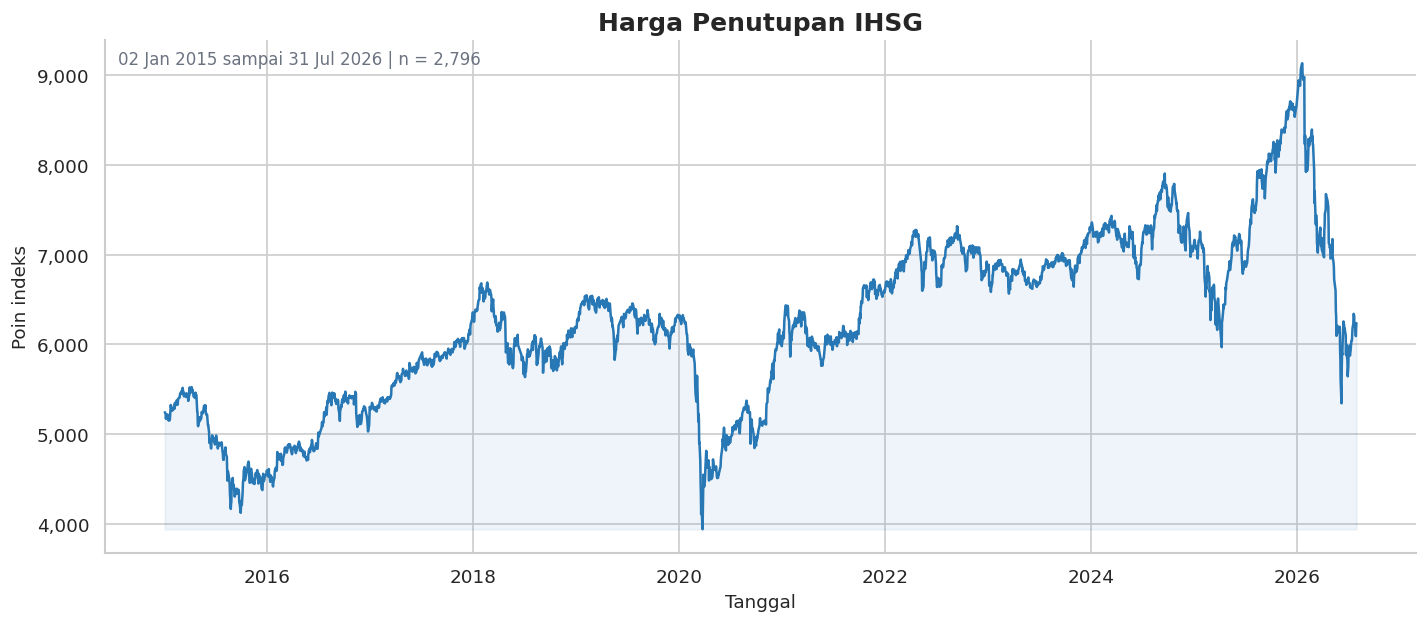

In [2]:
# TAHAP 2 - Unduh data IHSG otomatis dari Yahoo Finance
def yahoo_chart_download(ticker, start, end, interval="1d", retries=4):
    p1 = int(pd.Timestamp(start, tz="UTC").timestamp())
    p2 = int(pd.Timestamp(end, tz="UTC").timestamp())
    symbol = quote(ticker, safe="")
    hosts = ["query1.finance.yahoo.com", "query2.finance.yahoo.com"]
    errors = []

    for attempt in range(retries):
        for host in hosts:
            url = (f"https://{host}/v8/finance/chart/{symbol}"
                   f"?period1={p1}&period2={p2}&interval={interval}&events=history")
            try:
                response = requests.get(url, headers={"User-Agent":"Mozilla/5.0 (Kaggle IHSG Audit)"}, timeout=30)
                response.raise_for_status()
                payload = response.json()["chart"]
                if payload.get("error"):
                    raise RuntimeError(str(payload["error"]))
                result = payload["result"][0]
                quote_data = result["indicators"]["quote"][0]
                adj_data = result["indicators"].get("adjclose", [{}])[0].get("adjclose", quote_data["close"])
                dates = (pd.to_datetime(result["timestamp"], unit="s", utc=True)
                           .tz_convert("Asia/Jakarta").tz_localize(None).normalize())
                frame = pd.DataFrame({
                    "Open": quote_data["open"], "High": quote_data["high"],
                    "Low": quote_data["low"], "Close": quote_data["close"],
                    "Adj Close": adj_data, "Volume": quote_data["volume"],
                }, index=dates)
                frame.index.name = "Date"
                frame = frame[~frame.index.duplicated(keep="last")].sort_index()
                frame = frame.dropna(how="all")
                if len(frame) < 500:
                    raise ValueError(f"Data terlalu sedikit: {len(frame)} baris")
                return frame, host, result.get("meta", {})
            except Exception as exc:
                errors.append(f"percobaan {attempt+1}, {host}: {type(exc).__name__}: {exc}")
        time.sleep(1.5 * (attempt + 1))
    raise RuntimeError(
        "Unduhan IHSG gagal. Aktifkan Internet pada pengaturan Kaggle lalu jalankan ulang.\n" + "\n".join(errors[-4:])
    )

raw, source_host, source_meta = yahoo_chart_download(
    CONFIG["ticker"], CONFIG["start"], CONFIG["end"], CONFIG["interval"]
)

csv_bytes = raw.to_csv(index=True, float_format="%.8f").encode("utf-8")
DATA_HASH = hashlib.sha256(csv_bytes).hexdigest()
raw.to_csv(OUTPUT_DIR / "ihsg_raw_download.csv", index=True)

download_summary = pd.DataFrame({
    "Atribut": ["Simbol", "Bursa", "Mata uang", "Tanggal awal", "Tanggal akhir", "Jumlah observasi", "Host sumber", "SHA-256 data"],
    "Nilai": [CONFIG["ticker"], source_meta.get("exchangeName", "JKT"), source_meta.get("currency", "IDR"),
              raw.index.min().date(), raw.index.max().date(), len(raw), source_host, DATA_HASH],
})
show_table(download_summary, "Output Tahap 2A: Jejak Unduhan", precision=0)
show_table(raw.tail(8).reset_index(), "Output Tahap 2B: Delapan Observasi Terbaru", precision=2)

fig, ax = plt.subplots(figsize=(12, 5.3))
ax.plot(raw.index, raw["Close"], color=COLORS["blue"], linewidth=1.5)
ax.fill_between(raw.index, raw["Close"], raw["Close"].min(), color=COLORS["blue"], alpha=0.08)
ax.set(title="Harga Penutupan IHSG", xlabel="Tanggal", ylabel="Poin indeks")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:,.0f}")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.text(0.01, 0.98, f"{raw.index.min():%d %b %Y} sampai {raw.index.max():%d %b %Y} | n = {len(raw):,}",
        transform=ax.transAxes, va="top", color=COLORS["gray"])
save_show(fig, "01_harga_penutupan_ihsg.png")

,Pemeriksaan,Temuan,Kriteria lulus,Status
0,Indeks tanggal terurut,True,True,LULUS
1,Tanggal duplikat,0,0,LULUS
2,Close hilang,0,0,LULUS
3,Close tidak positif,0,0,LULUS
4,High < Low,0,0,LULUS
5,Open di luar rentang Low-High,0,0,LULUS
6,Close di luar rentang Low-High,0,0,LULUS
7,Lompatan tanggal > 7 hari,9,0,PERIKSA


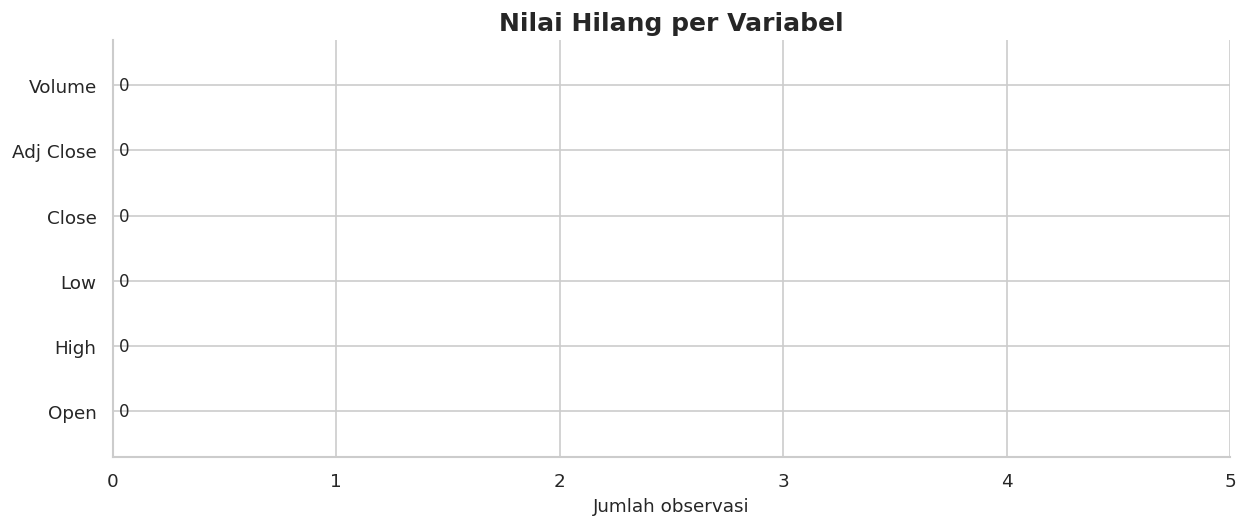

In [3]:
# TAHAP 3 - Audit kualitas data dan aturan OHLC
qa = pd.DataFrame({
    "Pemeriksaan": [
        "Indeks tanggal terurut", "Tanggal duplikat", "Close hilang", "Close tidak positif",
        "High < Low", "Open di luar rentang Low-High", "Close di luar rentang Low-High", "Lompatan tanggal > 7 hari"
    ],
    "Temuan": [
        bool(raw.index.is_monotonic_increasing), int(raw.index.duplicated().sum()), int(raw["Close"].isna().sum()),
        int((raw["Close"].dropna() <= 0).sum()), int((raw["High"] < raw["Low"]).fillna(False).sum()),
        int(((raw["Open"] < raw["Low"]) | (raw["Open"] > raw["High"])).fillna(False).sum()),
        int(((raw["Close"] < raw["Low"]) | (raw["Close"] > raw["High"])).fillna(False).sum()),
        int((raw.index.to_series().diff().dt.days > 7).sum()),
    ],
    "Kriteria lulus": [True, 0, 0, 0, 0, 0, 0, 0],
})
qa["Status"] = np.where(qa["Temuan"].astype(str) == qa["Kriteria lulus"].astype(str), "LULUS", "PERIKSA")
show_table(qa, "Output Tahap 3A: Audit Kualitas Data", precision=0)

missing = raw.isna().sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10.5, 4.5))
bars = ax.barh(missing.index, missing.values, color=[COLORS["orange"] if v else COLORS["teal"] for v in missing.values])
ax.bar_label(bars, padding=4, fmt="%d")
ax.set(title="Nilai Hilang per Variabel", xlabel="Jumlah observasi", ylabel="")
ax.set_xlim(0, max(5, missing.max() * 1.15))
save_show(fig, "02_audit_missing_value.png")

# Hanya baris dengan Close lengkap yang dipakai. Kolom lain tetap diperiksa melalui fitur yang membutuhkannya.
data = raw.dropna(subset=["Close"]).copy()
assert data.index.is_monotonic_increasing and data.index.is_unique
assert (data["Close"] > 0).all()

,Kelompok,Jumlah,Aturan waktu,Risiko kebocoran
0,Return lag,6,t-1 s.d. t-20,Rendah
1,Momentum,4,diakhiri pada t-1,Rendah
2,Volatilitas,4,diakhiri pada t-1,Rendah
3,Rentang intrahari,1,digeser 1 hari,Rendah
4,Perubahan volume,1,digeser 1 hari,Rendah
5,Target,2,Close dan return pada t+5,Dilarang menjadi fitur


,Date,return_lag_1,return_lag_2,return_lag_3,return_lag_5,return_lag_10,return_lag_20,momentum_5,momentum_10,momentum_20,momentum_60,volatility_5,volatility_10,volatility_20,volatility_60,range_lag_1,volume_change_lag_1,target_return
0,2026-07-17 00:00:00,0.01096,0.00041,0.00028,0.00202,0.02284,0.00078,0.03311,0.06330,-0.01039,-0.20424,0.00831,0.01163,0.01607,0.02088,0.01373,0.25597,0.00338
1,2026-07-20 00:00:00,0.01102,0.01096,0.00041,0.01916,0.00686,-0.00979,0.04240,0.05102,-0.00026,-0.18994,0.00805,0.01027,0.01627,0.02096,0.01835,-0.12496,-0.00738
2,2026-07-21 00:00:00,0.00911,0.01102,0.01096,0.00028,0.01190,-0.00251,0.03212,0.05336,0.01882,-0.18233,0.00554,0.01034,0.01621,0.02102,0.00945,0.37215,-0.03303
3,2026-07-22 00:00:00,0.01737,0.00911,0.01102,0.00041,-0.01890,-0.03564,0.04976,0.05905,0.03912,-0.16950,0.00610,0.01086,0.01659,0.02118,0.01462,0.56350,-0.03838
4,2026-07-23 00:00:00,-0.00087,0.01737,0.00911,0.01096,0.00665,0.01957,0.04841,0.07851,0.07658,-0.16587,0.00660,0.00718,0.01406,0.02118,0.01733,-0.04195,-0.02042
5,2026-07-24 00:00:00,-0.00303,-0.00087,0.01737,0.01102,0.00202,-0.01715,0.03391,0.06814,0.05272,-0.16457,0.00852,0.00793,0.01362,0.02118,0.02338,0.34969,0.00641


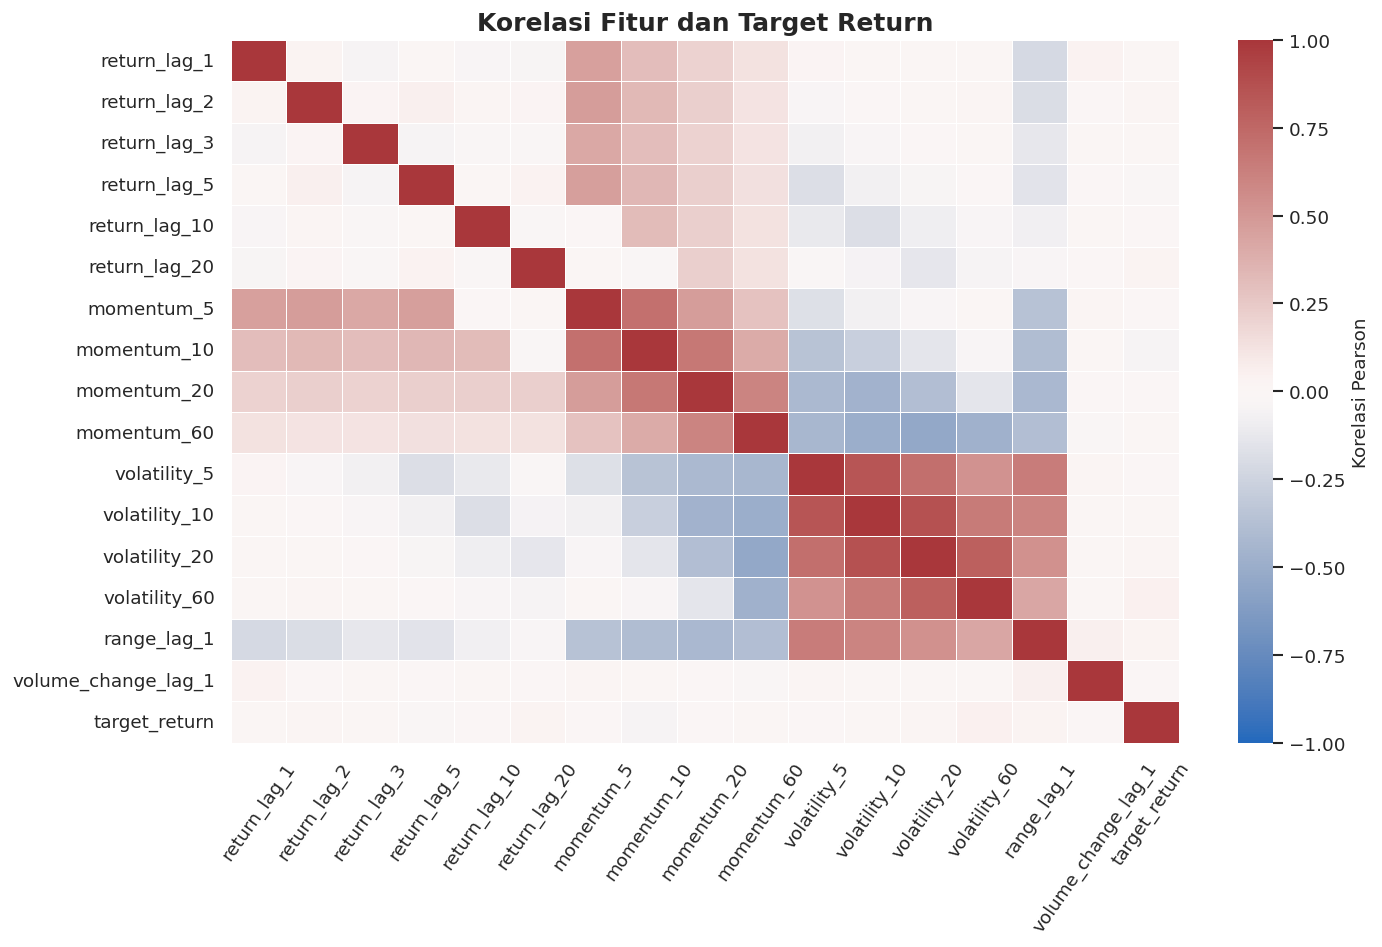

In [4]:
# TAHAP 4 - Feature engineering tanpa kebocoran waktu
H = CONFIG["horizon_hari_bursa"]
model_df = data.copy()
model_df["return_1"] = model_df["Close"].pct_change()

for lag in [1, 2, 3, 5, 10, 20]:
    model_df[f"return_lag_{lag}"] = model_df["return_1"].shift(lag)

for window in [5, 10, 20, 60]:
    model_df[f"momentum_{window}"] = model_df["Close"].pct_change(window).shift(1)
    model_df[f"volatility_{window}"] = model_df["return_1"].rolling(window).std().shift(1)

model_df["range_lag_1"] = ((model_df["High"] - model_df["Low"]) / model_df["Close"]).shift(1)
model_df["volume_change_lag_1"] = (model_df["Volume"].pct_change()
                                           .replace([np.inf, -np.inf], np.nan)
                                           .shift(1).clip(-5, 5))
model_df["target_close"] = model_df["Close"].shift(-H)
model_df["target_return"] = model_df["target_close"] / model_df["Close"] - 1
model_df["target_date"] = model_df.index.to_series().shift(-H)

FEATURES = ([f"return_lag_{x}" for x in [1,2,3,5,10,20]] +
            [f"momentum_{x}" for x in [5,10,20,60]] +
            [f"volatility_{x}" for x in [5,10,20,60]] +
            ["range_lag_1", "volume_change_lag_1"])

model_df = model_df.dropna(subset=FEATURES + ["target_close", "target_return", "target_date"]).copy()
assert (model_df["target_date"] > model_df.index.to_series()).all(), "Target harus terjadi setelah tanggal asal."

feature_dictionary = pd.DataFrame({
    "Kelompok": ["Return lag", "Momentum", "Volatilitas", "Rentang intrahari", "Perubahan volume", "Target"],
    "Jumlah": [6, 4, 4, 1, 1, 2],
    "Aturan waktu": ["t-1 s.d. t-20", "diakhiri pada t-1", "diakhiri pada t-1", "digeser 1 hari", "digeser 1 hari", f"Close dan return pada t+{H}"],
    "Risiko kebocoran": ["Rendah", "Rendah", "Rendah", "Rendah", "Rendah", "Dilarang menjadi fitur"],
})
show_table(feature_dictionary, "Output Tahap 4A: Kamus Fitur dan Batas Waktu", precision=0)
show_table(model_df[FEATURES + ["target_return"]].tail(6).reset_index(), "Output Tahap 4B: Sampel Data Model", precision=5)

corr_cols = FEATURES + ["target_return"]
corr = model_df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr, cmap="vlag", center=0, vmin=-1, vmax=1, linewidths=.3, cbar_kws={"label":"Korelasi Pearson"}, ax=ax)
ax.set_title("Korelasi Fitur dan Target Return")
ax.tick_params(axis="x", rotation=55)
ax.tick_params(axis="y", rotation=0)
save_show(fig, "03_korelasi_fitur.png")

,Bagian,Jumlah,Awal,Akhir,Tujuan
0,Latih,1905,2015-03-31,2023-02-06,Estimasi parameter
1,Validasi,272,2023-02-07,2024-03-28,Pemilihan model
2,Uji terkunci,545,2024-04-01,2026-07-24,Evaluasi final


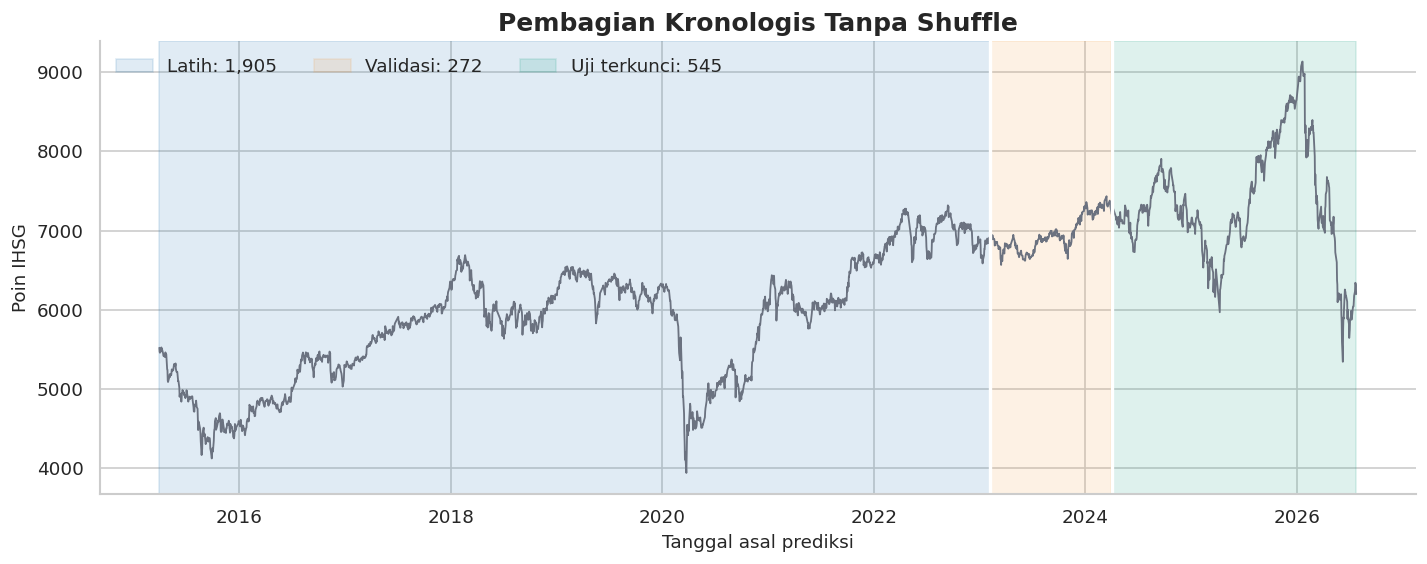

In [5]:
# TAHAP 5 - Pembagian kronologis 70/10/20
n = len(model_df)
train_end = int(n * CONFIG["train_ratio"])
val_end = int(n * (CONFIG["train_ratio"] + CONFIG["validation_ratio"]))
train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

assert train_df.index.max() < val_df.index.min() < test_df.index.min()
assert len(set(train_df.index) & set(test_df.index)) == 0

split_summary = pd.DataFrame([
    {"Bagian":"Latih", "Jumlah":len(train_df), "Awal":train_df.index.min().date(), "Akhir":train_df.index.max().date(), "Tujuan":"Estimasi parameter"},
    {"Bagian":"Validasi", "Jumlah":len(val_df), "Awal":val_df.index.min().date(), "Akhir":val_df.index.max().date(), "Tujuan":"Pemilihan model"},
    {"Bagian":"Uji terkunci", "Jumlah":len(test_df), "Awal":test_df.index.min().date(), "Akhir":test_df.index.max().date(), "Tujuan":"Evaluasi final"},
])
show_table(split_summary, "Output Tahap 5A: Pembagian Data Berdasarkan Waktu", precision=0)

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(model_df.index, model_df["Close"], color=COLORS["gray"], lw=1.1)
for part, frame, color in [("Latih",train_df,COLORS["blue"]),("Validasi",val_df,COLORS["orange"]),("Uji terkunci",test_df,COLORS["teal"])]:
    ax.axvspan(frame.index.min(), frame.index.max(), color=color, alpha=.14, label=f"{part}: {len(frame):,}")
ax.axvline(val_df.index.min(), color="white", lw=2)
ax.axvline(test_df.index.min(), color="white", lw=2)
ax.set(title="Pembagian Kronologis Tanpa Shuffle", xlabel="Tanggal asal prediksi", ylabel="Poin IHSG")
ax.legend(ncol=3, loc="upper left")
save_show(fig, "04_pembagian_waktu.png")

,Model,MAE,RMSE,MAPE (%),Directional Accuracy (%)
0,Naive t,61.5988,76.7290,0.8871,-
1,HistGradientBoosting,59.4929,76.9296,0.8573,59.9265
2,Ridge,65.0017,82.1301,0.9365,48.5294


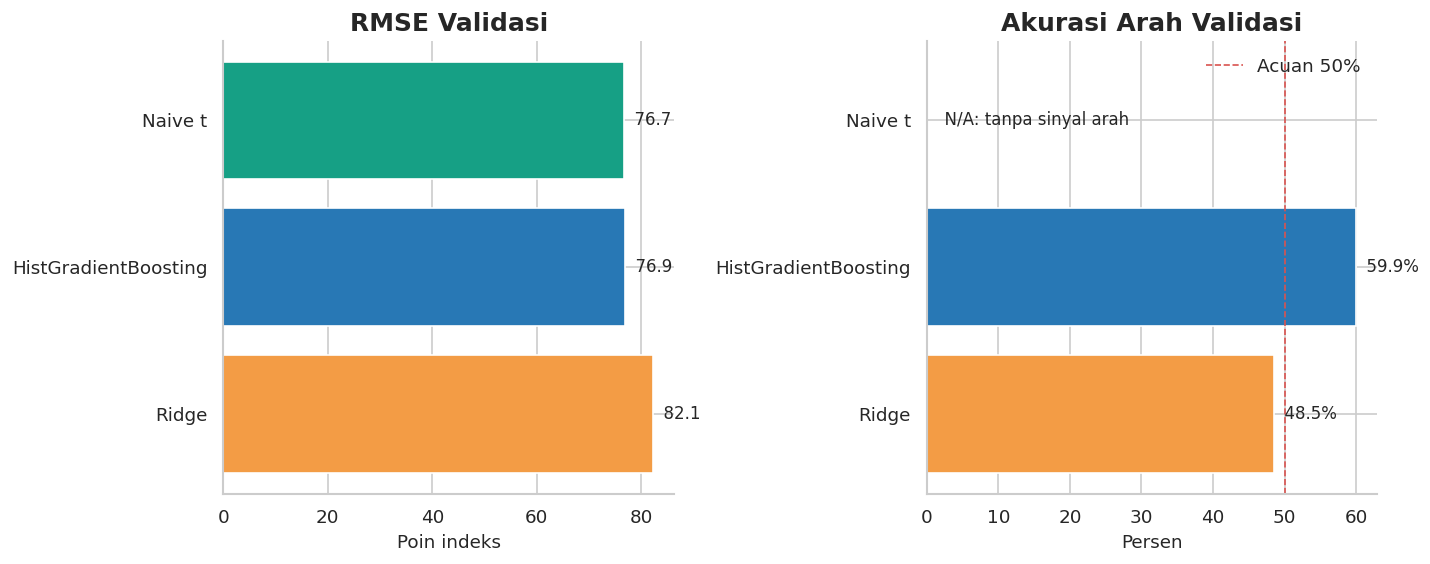

In [6]:
# TAHAP 6 - Seleksi model hanya pada validasi
SEED = CONFIG["random_seed"]
MODELS = {
    "Ridge": Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10.0))]),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.03, max_leaf_nodes=10,
        l2_regularization=2.0, random_state=SEED
    ),
}

def safe_mape(y_true, y_pred, epsilon=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > epsilon)
    if not mask.any():
        return np.nan
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def metric_row(name, frame, predicted_return):
    actual_price = frame["target_close"].to_numpy()
    origin_price = frame["Close"].to_numpy()
    pred_price = origin_price * (1 + np.asarray(predicted_return))
    actual_return = frame["target_return"].to_numpy()
    predicted_direction = np.sign(predicted_return)
    directional_accuracy = (np.nan if np.all(predicted_direction == 0) else
                            100 * np.mean(np.sign(actual_return) == predicted_direction))
    return {
        "Model": name,
        "MAE": mean_absolute_error(actual_price, pred_price),
        "RMSE": mean_squared_error(actual_price, pred_price) ** 0.5,
        "MAPE (%)": safe_mape(actual_price, pred_price),
        "Directional Accuracy (%)": directional_accuracy,
    }

validation_rows, validation_predictions = [], {}
for name, estimator in MODELS.items():
    fitted = clone(estimator).fit(train_df[FEATURES], train_df["target_return"])
    pred_ret = fitted.predict(val_df[FEATURES])
    validation_predictions[name] = pred_ret
    validation_rows.append(metric_row(name, val_df, pred_ret))

# Baseline tidak dilatih. Ia memprediksi harga t+5 sama dengan harga pada t.
validation_rows.append(metric_row("Naive t", val_df, np.zeros(len(val_df))))
validation_metrics = pd.DataFrame(validation_rows).sort_values("RMSE").reset_index(drop=True)

# Hanya model pembelajaran yang masuk proses seleksi. Baseline tetap menjadi pembanding wajib.
eligible = validation_metrics[validation_metrics["Model"].isin(MODELS)]
SELECTED_MODEL_NAME = eligible.iloc[0]["Model"]
show_table(validation_metrics, f"Output Tahap 6A: Hasil Validasi | Model terpilih: {SELECTED_MODEL_NAME}", precision=4)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
plot_order = validation_metrics.sort_values("RMSE", ascending=True)
axes[0].barh(plot_order["Model"], plot_order["RMSE"], color=[COLORS["teal"], COLORS["blue"], COLORS["orange"]])
axes[0].set(title="RMSE Validasi", xlabel="Poin indeks", ylabel="")
axes[0].invert_yaxis()
for i, v in enumerate(plot_order["RMSE"]): axes[0].text(v, i, f"  {v:,.1f}", va="center")
direction_values = plot_order["Directional Accuracy (%)"].fillna(0)
axes[1].barh(plot_order["Model"], direction_values, color=[COLORS["teal"], COLORS["blue"], COLORS["orange"]])
axes[1].axvline(50, color=COLORS["red"], ls="--", lw=1, label="Acuan 50%")
axes[1].set(title="Akurasi Arah Validasi", xlabel="Persen", ylabel="")
axes[1].invert_yaxis(); axes[1].legend(loc="upper right")
for i, v in enumerate(plot_order["Directional Accuracy (%)"]):
    label = "N/A: tanpa sinyal arah" if pd.isna(v) else f"{v:.1f}%"
    axes[1].text(1 if pd.isna(v) else v, i, f"  {label}", va="center")
save_show(fig, "05_seleksi_model_validasi.png")

,Kontrak,Nilai
0,Model final,HistGradientBoosting
1,Horizon,5 hari bursa
2,Tanggal asal pertama,2024-04-01
3,Tanggal target terakhir,2026-07-31
4,Jumlah pasangan,545
5,Missing,0
6,Tanggal duplikat,0
7,Hash objek final,df6a4e38ec71e65ac26b27797c715c88a672762d4f5cd234c8cd83600015e3e5


,origin_date,target_date,origin_close,actual_close,predicted_close,naive_close,actual_return,predicted_return,residual,absolute_error,absolute_percentage_error
535,2026-07-13 00:00:00,2026-07-20 00:00:00,6037.8418,6231.7798,6051.4712,6037.8418,0.0321,0.0023,180.3086,180.3086,2.8934
536,2026-07-14 00:00:00,2026-07-21 00:00:00,6039.5210,6340.0200,6002.3107,6039.5210,0.0498,-0.0062,337.7093,337.7093,5.3266
537,2026-07-15 00:00:00,2026-07-22 00:00:00,6041.9722,6334.4761,6253.1501,6041.9722,0.0484,0.0350,81.3260,81.3260,1.2839
538,2026-07-16 00:00:00,2026-07-23 00:00:00,6108.2090,6315.3110,6286.6313,6108.2090,0.0339,0.0292,28.6797,28.6797,0.4541
539,2026-07-17 00:00:00,2026-07-24 00:00:00,6175.5352,6196.4302,6352.6259,6175.5352,0.0034,0.0287,-156.1958,156.1958,2.5207
540,2026-07-20 00:00:00,2026-07-27 00:00:00,6231.7798,6185.7832,6442.9311,6231.7798,-0.0074,0.0339,-257.1479,257.1479,4.1571
541,2026-07-21 00:00:00,2026-07-28 00:00:00,6340.0200,6130.5879,6518.2471,6340.0200,-0.0330,0.0281,-387.6592,387.6592,6.3234
542,2026-07-22 00:00:00,2026-07-29 00:00:00,6334.4761,6091.3862,6448.6140,6334.4761,-0.0384,0.0180,-357.2277,357.2277,5.8645
543,2026-07-23 00:00:00,2026-07-30 00:00:00,6315.3110,6186.3628,6533.0787,6315.3110,-0.0204,0.0345,-346.7159,346.7159,5.6045
544,2026-07-24 00:00:00,2026-07-31 00:00:00,6196.4302,6236.1260,6423.1862,6196.4302,0.0064,0.0366,-187.0603,187.0603,2.9996


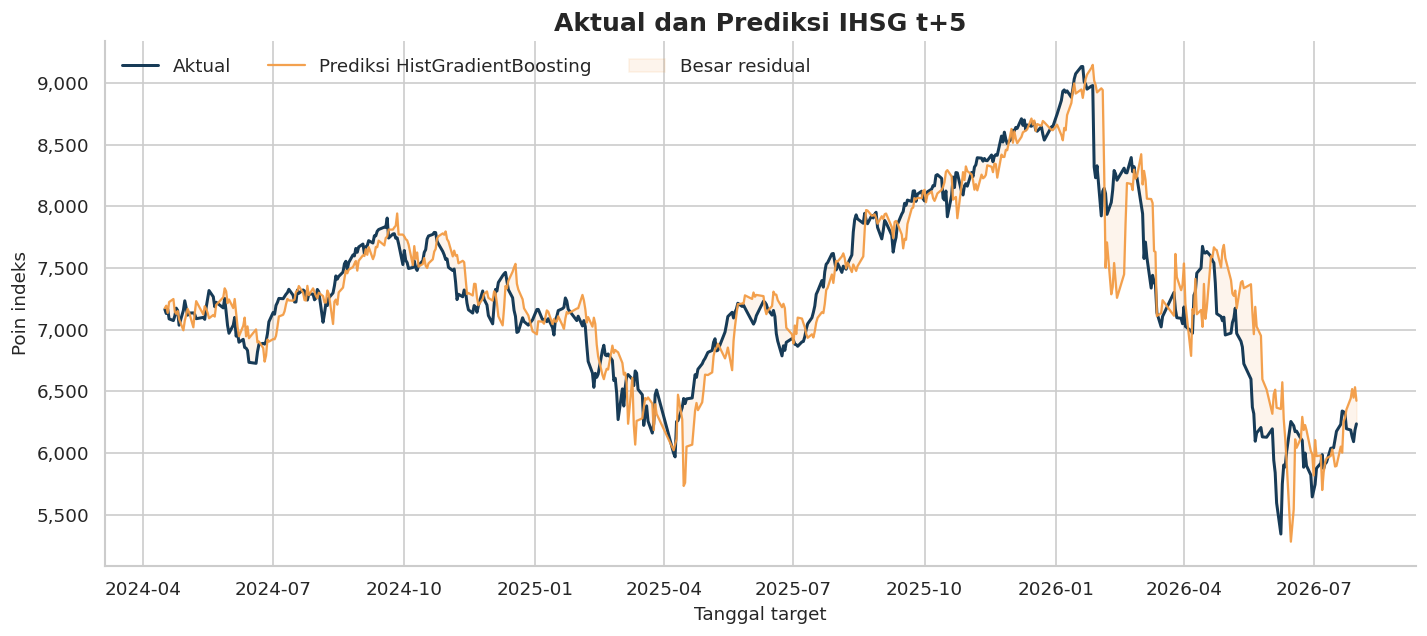

In [7]:
# TAHAP 7 - Latih ulang dan kunci objek prediksi final
development_df = pd.concat([train_df, val_df]).sort_index()
final_model = clone(MODELS[SELECTED_MODEL_NAME]).fit(development_df[FEATURES], development_df["target_return"])
pred_return_test = final_model.predict(test_df[FEATURES])

locked = pd.DataFrame({
    "origin_date": test_df.index,
    "target_date": pd.to_datetime(test_df["target_date"].values),
    "origin_close": test_df["Close"].to_numpy(),
    "actual_close": test_df["target_close"].to_numpy(),
    "predicted_close": test_df["Close"].to_numpy() * (1 + pred_return_test),
    "naive_close": test_df["Close"].to_numpy(),
    "actual_return": test_df["target_return"].to_numpy(),
    "predicted_return": pred_return_test,
})
locked["residual"] = locked["actual_close"] - locked["predicted_close"]
locked["absolute_error"] = locked["residual"].abs()
locked["absolute_percentage_error"] = 100 * locked["absolute_error"] / locked["actual_close"].abs()

# Kontrak data final. Program berhenti jika satu syarat gagal.
assert locked["origin_date"].is_monotonic_increasing
assert locked["origin_date"].is_unique and locked["target_date"].is_unique
assert not locked.isna().any().any()
assert (locked["target_date"] > locked["origin_date"]).all()
assert np.isfinite(locked.select_dtypes("number")).all().all()

LOCK_HASH = hashlib.sha256(locked.to_csv(index=False, float_format="%.10f").encode()).hexdigest()
locked.to_csv(OUTPUT_DIR / "prediksi_final_terkunci.csv", index=False)

lock_summary = pd.DataFrame({
    "Kontrak": ["Model final", "Horizon", "Tanggal asal pertama", "Tanggal target terakhir", "Jumlah pasangan", "Missing", "Tanggal duplikat", "Hash objek final"],
    "Nilai": [SELECTED_MODEL_NAME, f"{H} hari bursa", locked.origin_date.min().date(), locked.target_date.max().date(), len(locked), int(locked.isna().sum().sum()), int(locked.target_date.duplicated().sum()), LOCK_HASH],
})
show_table(lock_summary, "Output Tahap 7A: Kontrak Objek Prediksi Final", precision=0)
show_table(locked.tail(10), "Output Tahap 7B: Sepuluh Prediksi Final Terbaru", precision=4)

fig, ax = plt.subplots(figsize=(12, 5.4))
ax.plot(locked["target_date"], locked["actual_close"], label="Aktual", color=COLORS["navy"], lw=1.8)
ax.plot(locked["target_date"], locked["predicted_close"], label=f"Prediksi {SELECTED_MODEL_NAME}", color=COLORS["orange"], lw=1.35, alpha=.95)
ax.fill_between(locked["target_date"], locked["actual_close"], locked["predicted_close"], color=COLORS["orange"], alpha=.10, label="Besar residual")
ax.set(title=f"Aktual dan Prediksi IHSG t+{H}", xlabel="Tanggal target", ylabel="Poin indeks")
ax.legend(ncol=3, loc="upper left")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:,.0f}")
save_show(fig, "06_prediksi_final_terkunci.png")

,Objek evaluasi,n,MAE,RMSE,MAPE (%),Bias (aktual-prediksi),R²,Directional Accuracy (%)
0,"FINAL: HistGradientBoosting, test terkunci",545,191.9789,268.9797,2.7000,-20.9182,0.8657,52.8440
1,"PEMBANDING: Naive t, test sama",545,167.9347,224.9461,2.3590,-9.7613,0.9061,-


,Tes bug,Lulus,Nilai program,Nilai acuan
0,MAPE contoh manual,True,10.000000,10.000000
1,Timestamp aktual-prediksi sama,True,545,545
2,Tidak memakai target sebagai fitur,True,0,0
3,Test tidak dipakai memilih model,True,2024-04-01,2024-03-28


,Sumber angka,Periode/objek,Skala,MAPE (%),Status,Sumber kesalahan atau alasan,"Selisih dari 1,89 pp"
0,Abstrak/laporan lama,Tidak diketahui,Tidak diketahui,1.8900,BELUM SAH,"Data, skrip, skala, dan pasangan observasi belum terkunci",0.0000
1,Final audit,Test kronologis terkunci,"Harga IHSG t+5, skala asli",2.7000,SAH,Satu objek final; timestamp identik; test tidak dipakai memilih model,0.8100
2,Data pengembangan,Train+validasi,Harga IHSG t+5,1.0992,TIDAK BOLEH untuk klaim final,Galat in-sample cenderung optimistis,-0.7908
3,Split acak,Sampel acak seluruh periode,Harga IHSG t+5,1.4399,TIDAK SEBANDING,Urutan waktu rusak dan masa depan bercampur,-0.4501
4,Target bocor,Test terkunci,Target dimasukkan sebagai fitur,0.0000,BUG KRITIS,Model melihat jawaban,-1.8900
5,Skala salah,Test terkunci,Nilai z-score,61.3581,RUMUS TIDAK BERMAKNA,MAPE tidak valid pada skala berpusat nol,59.4681
6,Subset terpilih,50% galat terkecil,Harga IHSG t+5,0.9171,CHERRY-PICKING,Observasi sulit dibuang setelah hasil diketahui,-0.9729


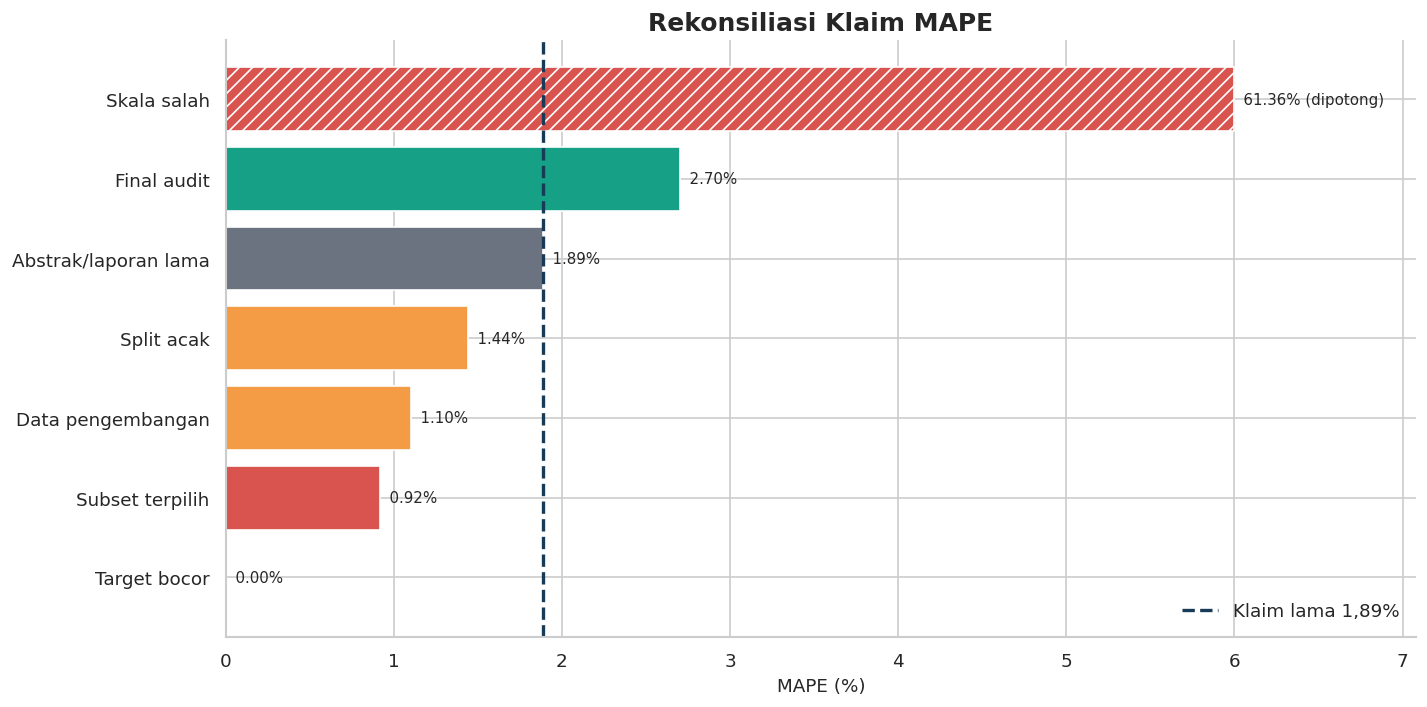

In [8]:
# TAHAP 8 - Audit fungsi metrik, bug, dan rekonsiliasi MAPE 1,89%
def all_metrics(actual, predicted, origin, name):
    actual, predicted, origin = map(lambda x: np.asarray(x, dtype=float), (actual, predicted, origin))
    residual = actual - predicted
    actual_direction = np.sign(actual - origin)
    predicted_direction = np.sign(predicted - origin)
    directional_accuracy = (np.nan if np.all(predicted_direction == 0) else
                            100 * np.mean(actual_direction == predicted_direction))
    return {
        "Objek evaluasi": name,
        "n": len(actual),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "MAPE (%)": safe_mape(actual, predicted),
        "Bias (aktual-prediksi)": residual.mean(),
        "R²": r2_score(actual, predicted),
        "Directional Accuracy (%)": directional_accuracy,
    }

final_metrics = pd.DataFrame([
    all_metrics(locked.actual_close, locked.predicted_close, locked.origin_close, f"FINAL: {SELECTED_MODEL_NAME}, test terkunci"),
    all_metrics(locked.actual_close, locked.naive_close, locked.origin_close, "PEMBANDING: Naive t, test sama"),
])
show_table(final_metrics, "Output Tahap 8A: Metrik Sah pada Timestamp Identik", precision=4)

# Unit test mendeteksi bug rumus dan ketidaksejajaran indeks.
toy_actual = np.array([100.0, 200.0, 400.0])
toy_pred = np.array([90.0, 220.0, 360.0])
expected_toy_mape = (10/100 + 20/200 + 40/400) / 3 * 100
tests = []
tests.append(("MAPE contoh manual", np.isclose(safe_mape(toy_actual, toy_pred), expected_toy_mape), safe_mape(toy_actual, toy_pred), expected_toy_mape))
tests.append(("Timestamp aktual-prediksi sama", locked.origin_date.is_unique and locked.target_date.is_unique, len(locked), len(locked)))
tests.append(("Tidak memakai target sebagai fitur", "target_return" not in FEATURES and "target_close" not in FEATURES, 0, 0))
tests.append(("Test tidak dipakai memilih model", test_df.index.min() > val_df.index.max(), test_df.index.min().date(), val_df.index.max().date()))
unit_tests = pd.DataFrame(tests, columns=["Tes bug", "Lulus", "Nilai program", "Nilai acuan"])
show_table(unit_tests, "Output Tahap 8B: Unit Test Logika Evaluasi", precision=6)
assert unit_tests["Lulus"].all()

# Kandidat sumber angka lama. Ini diagnosis, bukan bukti asal angka tanpa skrip laporan asli.
dev_pred_ret = final_model.predict(development_df[FEATURES])
dev_pred_price = development_df["Close"].to_numpy() * (1 + dev_pred_ret)
development_mape = safe_mape(development_df["target_close"], dev_pred_price)

# Kesalahan 1: random split mengabaikan urutan waktu.
random_train, random_test = train_test_split(model_df, test_size=CONFIG["test_ratio"], shuffle=True, random_state=SEED)
random_model = clone(MODELS[SELECTED_MODEL_NAME]).fit(random_train[FEATURES], random_train["target_return"])
random_pred_price = random_test["Close"].to_numpy() * (1 + random_model.predict(random_test[FEATURES]))
random_mape = safe_mape(random_test["target_close"], random_pred_price)

# Kesalahan 2: target bocor dimasukkan sebagai fitur. Hasil ini sengaja dibuat untuk mendemonstrasikan bug.
leaky_X_train = development_df[FEATURES].copy(); leaky_X_test = test_df[FEATURES].copy()
leaky_X_train["BUG_target_return"] = development_df["target_return"]
leaky_X_test["BUG_target_return"] = test_df["target_return"]
leaky_model = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=0.001))]).fit(leaky_X_train, development_df["target_return"])
leaky_pred_price = test_df["Close"].to_numpy() * (1 + leaky_model.predict(leaky_X_test))
leaky_mape = safe_mape(test_df["target_close"], leaky_pred_price)

# Kesalahan 3: MAPE dihitung pada nilai standardisasi. Penyebut dapat mendekati nol dan hasil tidak bermakna.
z_actual = (locked.actual_close - development_df.target_close.mean()) / development_df.target_close.std(ddof=0)
z_pred = (locked.predicted_close - development_df.target_close.mean()) / development_df.target_close.std(ddof=0)
wrong_scaled_mape = safe_mape(z_actual, z_pred)

# Kesalahan 4: hanya melaporkan 50% observasi dengan APE terkecil setelah melihat hasil.
cherry_n = len(locked) // 2
cherry_mape = locked.nsmallest(cherry_n, "absolute_percentage_error")["absolute_percentage_error"].mean()

valid_final_mape = float(final_metrics.iloc[0]["MAPE (%)"])
reconciliation = pd.DataFrame([
    ["Abstrak/laporan lama", "Tidak diketahui", "Tidak diketahui", CONFIG["reported_mape_percent"], "BELUM SAH", "Data, skrip, skala, dan pasangan observasi belum terkunci"],
    ["Final audit", "Test kronologis terkunci", "Harga IHSG t+5, skala asli", valid_final_mape, "SAH", "Satu objek final; timestamp identik; test tidak dipakai memilih model"],
    ["Data pengembangan", "Train+validasi", "Harga IHSG t+5", development_mape, "TIDAK BOLEH untuk klaim final", "Galat in-sample cenderung optimistis"],
    ["Split acak", "Sampel acak seluruh periode", "Harga IHSG t+5", random_mape, "TIDAK SEBANDING", "Urutan waktu rusak dan masa depan bercampur"],
    ["Target bocor", "Test terkunci", "Target dimasukkan sebagai fitur", leaky_mape, "BUG KRITIS", "Model melihat jawaban"],
    ["Skala salah", "Test terkunci", "Nilai z-score", wrong_scaled_mape, "RUMUS TIDAK BERMAKNA", "MAPE tidak valid pada skala berpusat nol"],
    ["Subset terpilih", "50% galat terkecil", "Harga IHSG t+5", cherry_mape, "CHERRY-PICKING", "Observasi sulit dibuang setelah hasil diketahui"],
], columns=["Sumber angka", "Periode/objek", "Skala", "MAPE (%)", "Status", "Sumber kesalahan atau alasan"])
reconciliation["Selisih dari 1,89 pp"] = reconciliation["MAPE (%)"] - CONFIG["reported_mape_percent"]
reconciliation.to_csv(OUTPUT_DIR / "tabel_rekonsiliasi_metrik.csv", index=False)
show_table(reconciliation, "Output Tahap 8C: Tabel Rekonsiliasi MAPE", precision=4)

plot_rec = reconciliation[np.isfinite(reconciliation["MAPE (%)"])].copy().sort_values("MAPE (%)")
fig, ax = plt.subplots(figsize=(12, 6))
status_colors = {"SAH":COLORS["teal"], "BELUM SAH":COLORS["gray"], "TIDAK BOLEH untuk klaim final":COLORS["orange"],
                 "TIDAK SEBANDING":COLORS["orange"], "BUG KRITIS":COLORS["red"], "RUMUS TIDAK BERMAKNA":COLORS["red"], "CHERRY-PICKING":COLORS["red"]}
chart_cap = max(6.0, valid_final_mape * 1.8)
display_mape = plot_rec["MAPE (%)"].clip(upper=chart_cap)
bars = ax.barh(plot_rec["Sumber angka"], display_mape, color=[status_colors[x] for x in plot_rec["Status"]])
ax.axvline(CONFIG["reported_mape_percent"], color=COLORS["navy"], ls="--", lw=2, label="Klaim lama 1,89%")
ax.set(title="Rekonsiliasi Klaim MAPE", xlabel="MAPE (%)", ylabel="")
ax.set_xlim(0, chart_cap * 1.18)
ax.legend(loc="lower right")
for bar, value in zip(bars, plot_rec["MAPE (%)"]):
    clipped = value > chart_cap
    if clipped:
        bar.set_hatch("///")
    label = f"  {value:.2f}%" + (" (dipotong)" if clipped else "")
    ax.text(bar.get_width(), bar.get_y()+bar.get_height()/2, label, va="center", fontsize=9)
save_show(fig, "07_rekonsiliasi_mape.png")

,Statistik,Nilai,Unit
0,Rata-rata/bias,-20.9182,poin
1,Median,-2.7547,poin
2,Simpangan baku,268.4114,poin
3,Minimum,-1090.2947,poin
4,Maksimum,974.6553,poin
5,Skewness,-0.2962,tanpa unit
6,Kurtosis berlebih,2.4996,tanpa unit
7,APE P95,8.9709,%


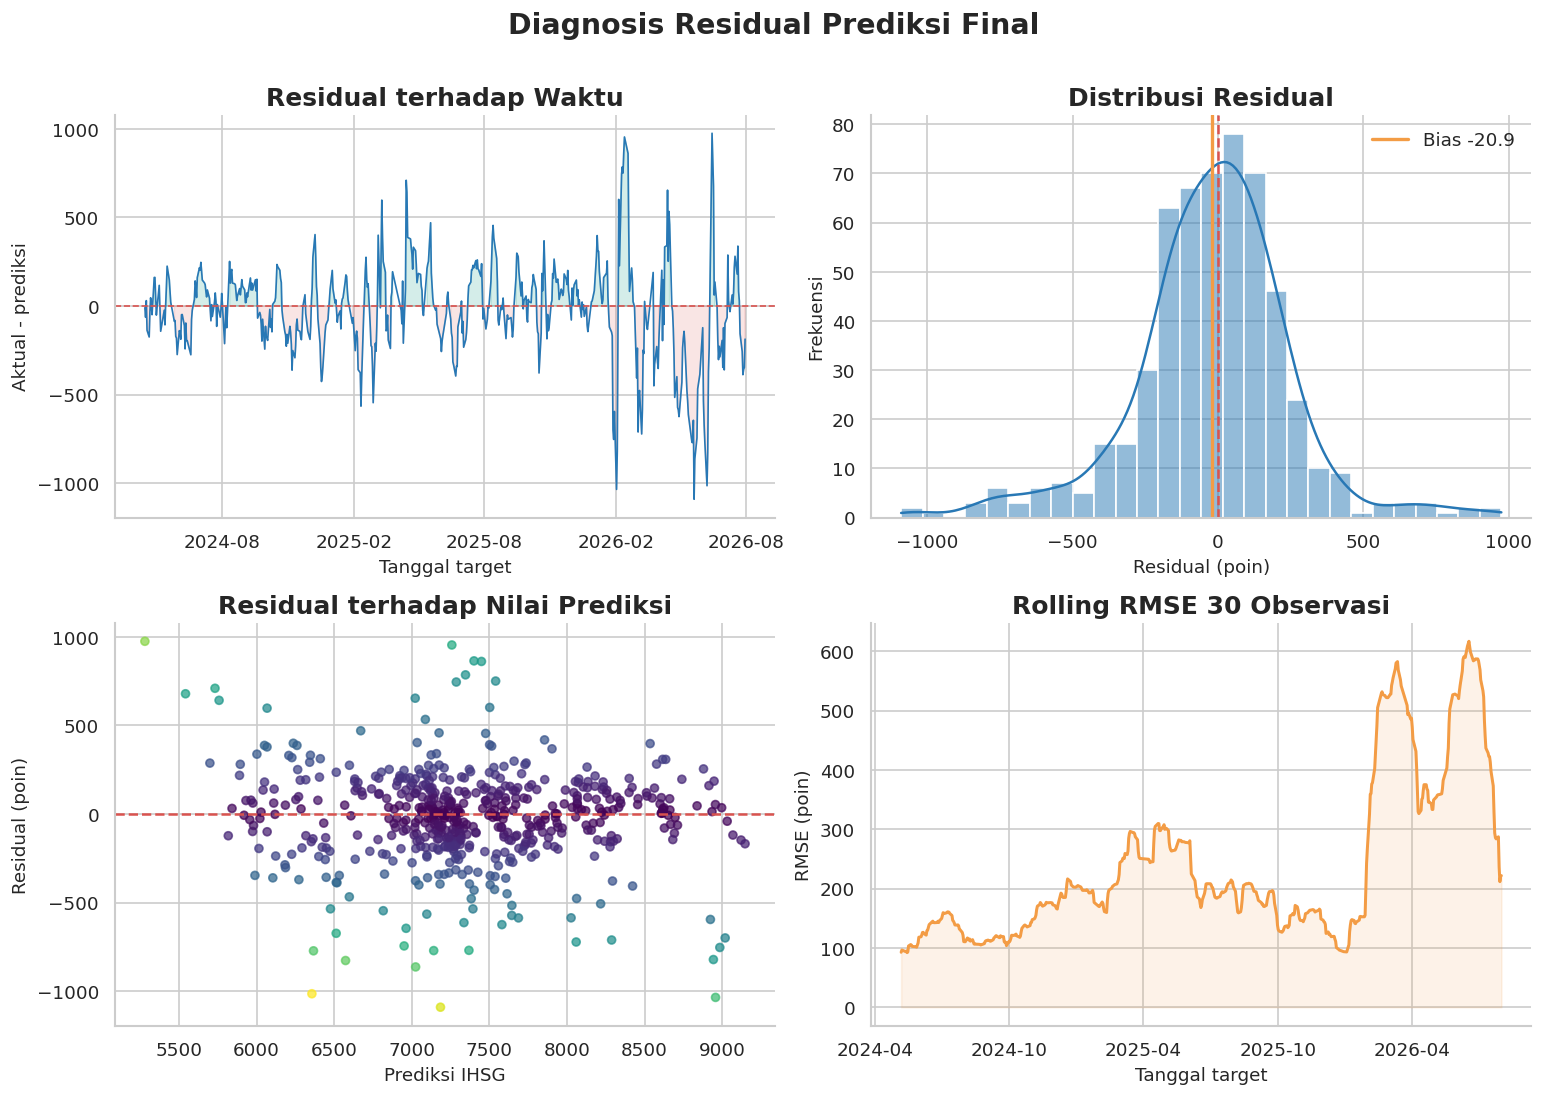

In [9]:
# TAHAP 9 - Diagnosis residual final
residual_summary = pd.DataFrame({
    "Statistik": ["Rata-rata/bias", "Median", "Simpangan baku", "Minimum", "Maksimum", "Skewness", "Kurtosis berlebih", "APE P95"],
    "Nilai": [locked.residual.mean(), locked.residual.median(), locked.residual.std(ddof=1), locked.residual.min(),
              locked.residual.max(), stats.skew(locked.residual, bias=False), stats.kurtosis(locked.residual, bias=False),
              locked.absolute_percentage_error.quantile(.95)],
    "Unit": ["poin", "poin", "poin", "poin", "poin", "tanpa unit", "tanpa unit", "%"],
})
show_table(residual_summary, "Output Tahap 9A: Ringkasan Residual", precision=4)

rolling_rmse = locked.set_index("target_date")["residual"].pow(2).rolling(30, min_periods=15).mean().pow(.5)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].plot(locked.target_date, locked.residual, color=COLORS["blue"], lw=1)
axes[0,0].axhline(0, color=COLORS["red"], ls="--", lw=1)
axes[0,0].fill_between(locked.target_date, 0, locked.residual, where=locked.residual>=0, color=COLORS["teal"], alpha=.18)
axes[0,0].fill_between(locked.target_date, 0, locked.residual, where=locked.residual<0, color=COLORS["red"], alpha=.15)
axes[0,0].set(title="Residual terhadap Waktu", xlabel="Tanggal target", ylabel="Aktual - prediksi")
axes[0,0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

sns.histplot(locked.residual, bins=28, kde=True, color=COLORS["blue"], ax=axes[0,1])
axes[0,1].axvline(0, color=COLORS["red"], ls="--")
axes[0,1].axvline(locked.residual.mean(), color=COLORS["orange"], lw=2, label=f"Bias {locked.residual.mean():,.1f}")
axes[0,1].set(title="Distribusi Residual", xlabel="Residual (poin)", ylabel="Frekuensi")
axes[0,1].legend()

axes[1,0].scatter(locked.predicted_close, locked.residual, c=locked.absolute_percentage_error, cmap="viridis", s=23, alpha=.72)
axes[1,0].axhline(0, color=COLORS["red"], ls="--")
axes[1,0].set(title="Residual terhadap Nilai Prediksi", xlabel="Prediksi IHSG", ylabel="Residual (poin)")

axes[1,1].plot(rolling_rmse.index, rolling_rmse, color=COLORS["orange"], lw=1.8)
axes[1,1].fill_between(rolling_rmse.index, 0, rolling_rmse, color=COLORS["orange"], alpha=.12)
axes[1,1].set(title="Rolling RMSE 30 Observasi", xlabel="Tanggal target", ylabel="RMSE (poin)")
axes[1,1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[1,1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

fig.suptitle("Diagnosis Residual Prediksi Final", fontsize=17, fontweight="bold", y=1.01)
save_show(fig, "08_diagnosis_residual.png")

,Perbandingan,Loss,n identik,Horizon,DM-HLN,p-value,Arah rata-rata loss,Keputusan
0,HistGradientBoosting vs Naive t,Squared error,545,5,2.812976,0.005086,Baseline naif lebih akurat,Tolak H0 pada 5%


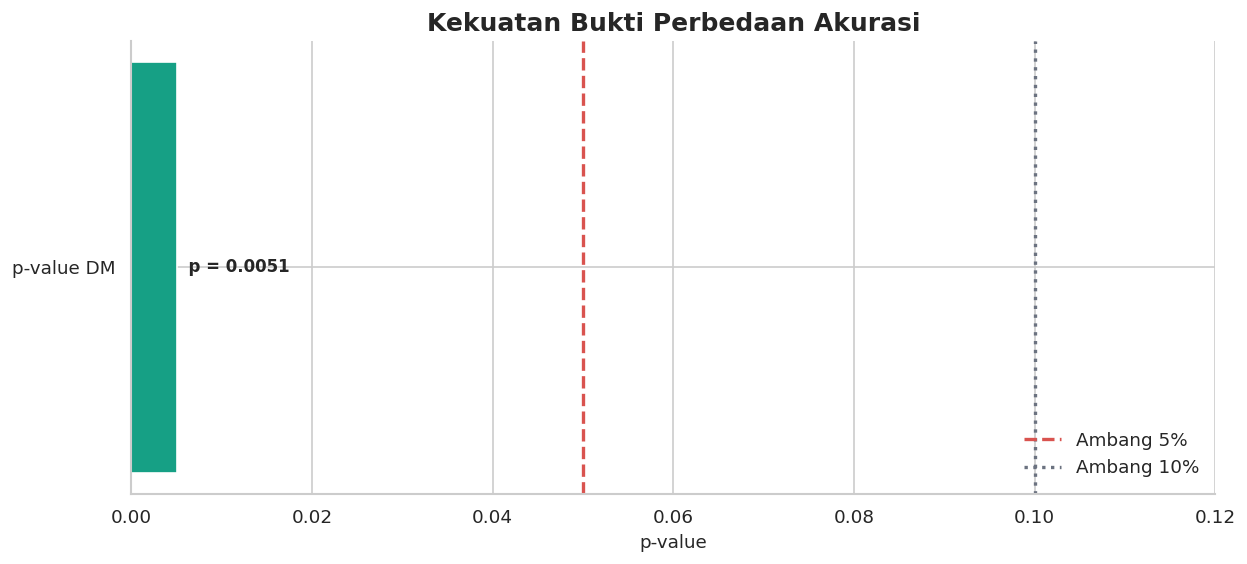

In [10]:
# TAHAP 10 - Uji Diebold-Mariano pada target dan timestamp identik
def diebold_mariano(loss_a, loss_b, horizon=1, max_lag=None):
    a, b = np.asarray(loss_a, float), np.asarray(loss_b, float)
    if len(a) != len(b):
        raise ValueError("Kedua model wajib memiliki jumlah observasi yang sama.")
    d = a - b  # negatif berarti model A lebih baik
    n = len(d)
    lag = horizon - 1 if max_lag is None else max_lag
    centered = d - d.mean()
    gamma0 = np.dot(centered, centered) / n
    long_run_var = gamma0
    for k in range(1, min(lag, n-1) + 1):
        gamma = np.dot(centered[k:], centered[:-k]) / n
        weight = 1 - k / (lag + 1)  # Bartlett/Newey-West
        long_run_var += 2 * weight * gamma
    if long_run_var <= 0:
        return np.nan, np.nan, d.mean()
    dm = d.mean() / np.sqrt(long_run_var / n)
    correction = np.sqrt((n + 1 - 2*horizon + horizon*(horizon-1)/n) / n)
    dm_hln = dm * correction
    p_value = 2 * stats.t.sf(abs(dm_hln), df=n-1)
    return dm_hln, p_value, d.mean()

# Syarat utama diuji eksplisit, bukan diasumsikan.
assert locked.target_date.is_unique
assert len(locked.predicted_close) == len(locked.naive_close) == len(locked.actual_close)
loss_model = (locked.actual_close - locked.predicted_close) ** 2
loss_naive = (locked.actual_close - locked.naive_close) ** 2
dm_stat, dm_p, mean_loss_diff = diebold_mariano(loss_model, loss_naive, horizon=H)

dm_direction = ("Model final lebih akurat" if mean_loss_diff < 0 else "Baseline naif lebih akurat")
dm_decision = "Tolak H0 pada 5%" if dm_p < .05 else "Belum menolak H0 pada 5%"
dm_table = pd.DataFrame({
    "Perbandingan": [f"{SELECTED_MODEL_NAME} vs Naive t"],
    "Loss": ["Squared error"], "n identik": [len(locked)], "Horizon": [H],
    "DM-HLN": [dm_stat], "p-value": [dm_p], "Arah rata-rata loss": [dm_direction], "Keputusan": [dm_decision],
})
show_table(dm_table, "Output Tahap 10A: Uji Diebold-Mariano", precision=6)

fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.barh(["p-value DM"], [dm_p], color=COLORS["teal"] if dm_p < .05 else COLORS["orange"], height=.42)
ax.axvline(.05, color=COLORS["red"], ls="--", lw=2, label="Ambang 5%")
ax.axvline(.10, color=COLORS["gray"], ls=":", lw=2, label="Ambang 10%")
ax.text(dm_p, 0, f"  p = {dm_p:.4f}", va="center", fontweight="bold")
ax.set_xlim(0, max(.12, min(1, dm_p * 1.25)))
ax.set(title="Kekuatan Bukti Perbedaan Akurasi", xlabel="p-value", ylabel="")
ax.legend(loc="lower right")
save_show(fig, "09_uji_diebold_mariano.png")

In [11]:
# TAHAP 11 - Analisis kritis dan memo koreksi internal otomatis
reported = CONFIG["reported_mape_percent"]
delta = valid_final_mape - reported
closest_candidates = reconciliation[reconciliation["Sumber angka"] != "Abstrak/laporan lama"].copy()
closest_candidates["Jarak absolut"] = (closest_candidates["MAPE (%)"] - reported).abs()
closest = closest_candidates.sort_values("Jarak absolut").iloc[0]

if abs(delta) < 0.01:
    claim_status = "Klaim 1,89% berdekatan dengan hasil audit, tetapi hanya angka audit dengan objek terkunci yang boleh digunakan."
elif delta > 0:
    claim_status = f"Klaim 1,89% terlalu optimistis sebesar {delta:.2f} poin persentase dibanding MAPE final."
else:
    claim_status = f"Klaim 1,89% lebih tinggi sebesar {abs(delta):.2f} poin persentase dibanding MAPE final."

memo = f'''MEMO KOREKSI INTERNAL - AUDIT METRIK IHSG
Tanggal eksekusi: {pd.Timestamp.now(tz='Asia/Jakarta'):%d-%m-%Y %H:%M WIB}
Objek final: harga penutupan IHSG {H} hari bursa ke depan
Model final: {SELECTED_MODEL_NAME}
Periode uji: {locked.origin_date.min():%d-%m-%Y} sampai {locked.target_date.max():%d-%m-%Y}
Jumlah pasangan observasi identik: {len(locked)}
Hash data: {DATA_HASH}
Hash objek prediksi: {LOCK_HASH}

TEMUAN
Laporan lama mencantumkan MAPE 1,89%, tetapi tidak menyertakan objek prediksi, periode, skala, rumus, dan hash data yang dapat diverifikasi. {claim_status}
Hasil audit pada test kronologis terkunci menghasilkan MAPE {valid_final_mape:.4f}%, MAE {final_metrics.iloc[0]['MAE']:.4f} poin, RMSE {final_metrics.iloc[0]['RMSE']:.4f} poin, bias {final_metrics.iloc[0]['Bias (aktual-prediksi)']:.4f} poin, dan Directional Accuracy {final_metrics.iloc[0]['Directional Accuracy (%)']:.2f}%.

REKONSILIASI
Kandidat angka yang paling dekat dengan 1,89% adalah '{closest['Sumber angka']}' dengan MAPE {closest['MAPE (%)']:.4f}%. Kedekatan numerik bukan bukti asal angka. Sumber sebenarnya hanya dapat dipastikan dari skrip, artefak prediksi, dan log eksekusi laporan lama. Perhitungan dengan target bocor, skala z-score, split acak, data pengembangan, atau subset terpilih tidak boleh menggantikan hasil test terkunci.

KEPUTUSAN
Gunakan MAPE {valid_final_mape:.4f}% sebagai angka sah untuk konfigurasi, periode, horizon, model, dan hash yang tercatat di memo ini. Cantumkan metrik baseline dan hasil uji Diebold-Mariano agar pembaca dapat menilai nilai tambah model. Status DM: {dm_decision}, p={dm_p:.6f}; arah rata-rata loss: {dm_direction}.

PENCEGAHAN
1. Simpan satu tabel prediksi final dengan origin_date dan target_date.
2. Hitung semua metrik dari tabel dan pasangan observasi yang sama.
3. Larang shuffle, target leakage, dan pemilihan subset setelah melihat galat.
4. Jalankan unit test MAPE, kontrak timestamp, dan pemeriksaan skala sebelum publikasi.
5. Arsipkan konfigurasi, versi pustaka, seed, hash data, dan hash prediksi.
'''
(OUTPUT_DIR / "memo_koreksi_internal.txt").write_text(memo, encoding="utf-8")

with open(OUTPUT_DIR / "konfigurasi_dan_hash.json", "w", encoding="utf-8") as f:
    json.dump({**CONFIG, "data_sha256": DATA_HASH, "locked_prediction_sha256": LOCK_HASH,
               "selected_model": SELECTED_MODEL_NAME}, f, indent=2, ensure_ascii=False)

display(Markdown("### Output Tahap 11A: Memo Koreksi Internal"))
display(Markdown("```text\n" + memo + "\n```"))

decision = pd.DataFrame({
    "Pertanyaan kritis": [
        "Apakah 1,89% dapat direplikasi?", "Apakah seluruh metrik memakai objek sama?",
        "Apakah residual bebas bias besar?", "Apakah model mengalahkan baseline?", "Angka mana yang dilaporkan?"
    ],
    "Jawaban audit": [
        "Belum, tanpa skrip dan artefak lama", "Ya, pada objek final terkunci",
        f"Bias = {locked.residual.mean():,.2f} poin; periksa pola grafik",
        f"{dm_direction}; {dm_decision}", f"MAPE final {valid_final_mape:.4f}%"
    ],
    "Implikasi": [
        "Jangan mempertahankan klaim hanya karena terlihat unggul", "MAE, RMSE, MAPE, residual, dan DM dapat dibandingkan",
        "R² atau MAPE saja tidak cukup", "Kompleksitas model harus memberi manfaat terukur", "Gunakan periode, horizon, hash, dan versi yang sama"
    ],
})
show_table(decision, "Output Tahap 11B: Keputusan Audit", precision=4)

output_files = pd.DataFrame({"File keluaran": sorted(p.name for p in OUTPUT_DIR.iterdir())})
show_table(output_files, f"Output Tahap 11C: Artefak Tersimpan di {OUTPUT_DIR}", precision=0)

### Output Tahap 11A: Memo Koreksi Internal

```text
MEMO KOREKSI INTERNAL - AUDIT METRIK IHSG
Tanggal eksekusi: 01-08-2026 18:27 WIB
Objek final: harga penutupan IHSG 5 hari bursa ke depan
Model final: HistGradientBoosting
Periode uji: 01-04-2024 sampai 31-07-2026
Jumlah pasangan observasi identik: 545
Hash data: be22a2de38df49f3011ce9a5311c2d2101d9dab47a2a2e380a3ac4662af8d3b0
Hash objek prediksi: df6a4e38ec71e65ac26b27797c715c88a672762d4f5cd234c8cd83600015e3e5

TEMUAN
Laporan lama mencantumkan MAPE 1,89%, tetapi tidak menyertakan objek prediksi, periode, skala, rumus, dan hash data yang dapat diverifikasi. Klaim 1,89% terlalu optimistis sebesar 0.81 poin persentase dibanding MAPE final.
Hasil audit pada test kronologis terkunci menghasilkan MAPE 2.7000%, MAE 191.9789 poin, RMSE 268.9797 poin, bias -20.9182 poin, dan Directional Accuracy 52.84%.

REKONSILIASI
Kandidat angka yang paling dekat dengan 1,89% adalah 'Split acak' dengan MAPE 1.4399%. Kedekatan numerik bukan bukti asal angka. Sumber sebenarnya hanya dapat dipastikan dari skrip, artefak prediksi, dan log eksekusi laporan lama. Perhitungan dengan target bocor, skala z-score, split acak, data pengembangan, atau subset terpilih tidak boleh menggantikan hasil test terkunci.

KEPUTUSAN
Gunakan MAPE 2.7000% sebagai angka sah untuk konfigurasi, periode, horizon, model, dan hash yang tercatat di memo ini. Cantumkan metrik baseline dan hasil uji Diebold-Mariano agar pembaca dapat menilai nilai tambah model. Status DM: Tolak H0 pada 5%, p=0.005086; arah rata-rata loss: Baseline naif lebih akurat.

PENCEGAHAN
1. Simpan satu tabel prediksi final dengan origin_date dan target_date.
2. Hitung semua metrik dari tabel dan pasangan observasi yang sama.
3. Larang shuffle, target leakage, dan pemilihan subset setelah melihat galat.
4. Jalankan unit test MAPE, kontrak timestamp, dan pemeriksaan skala sebelum publikasi.
5. Arsipkan konfigurasi, versi pustaka, seed, hash data, dan hash prediksi.

```

,Pertanyaan kritis,Jawaban audit,Implikasi
0,"Apakah 1,89% dapat direplikasi?","Belum, tanpa skrip dan artefak lama",Jangan mempertahankan klaim hanya karena terlihat unggul
1,Apakah seluruh metrik memakai objek sama?,"Ya, pada objek final terkunci","MAE, RMSE, MAPE, residual, dan DM dapat dibandingkan"
2,Apakah residual bebas bias besar?,Bias = -20.92 poin; periksa pola grafik,R² atau MAPE saja tidak cukup
3,Apakah model mengalahkan baseline?,Baseline naif lebih akurat; Tolak H0 pada 5%,Kompleksitas model harus memberi manfaat terukur
4,Angka mana yang dilaporkan?,MAPE final 2.7000%,"Gunakan periode, horizon, hash, dan versi yang sama"


,File keluaran
0,01_harga_penutupan_ihsg.png
1,02_audit_missing_value.png
2,03_korelasi_fitur.png
3,04_pembagian_waktu.png
4,05_seleksi_model_validasi.png
5,06_prediksi_final_terkunci.png
6,07_rekonsiliasi_mape.png
7,08_diagnosis_residual.png
8,09_uji_diebold_mariano.png
9,ihsg_raw_download.csv


## 12. Interpretasi Logis

MAPE 1,89% tidak otomatis benar atau salah hanya karena grafik terlihat memiliki beberapa galat besar. MAPE merata-ratakan kesalahan persentase, sedangkan grafik dapat menonjolkan pencilan tertentu. Audit yang valid harus membandingkan klaim tersebut dengan pasangan aktual dan prediksi yang sama. Notebook ini mengunci tanggal asal, tanggal target, horizon, skala harga, model, dan hash data sebelum menghitung metrik. Jika MAPE audit berbeda dari 1,89%, laporan harus memakai angka audit dan menjelaskan selisihnya. Kandidat angka yang dekat secara numerik tidak membuktikan sumber kesalahan. Bukti asal angka memerlukan skrip dan artefak lama.

Residual menambah informasi yang tidak diberikan MAPE. Bias rata-rata menunjukkan kecenderungan prediksi terlalu rendah atau tinggi. Plot residual terhadap waktu memeriksa perubahan rezim. Plot residual terhadap prediksi memeriksa perubahan variansi. Rolling RMSE menunjukkan periode ketika model kehilangan stabilitas. Uji Diebold-Mariano membandingkan kerugian model dan baseline pada timestamp identik. Nilai p tidak boleh dibaca tanpa arah rata-rata selisih loss. Jika baseline naif setara atau lebih baik, model yang lebih kompleks belum memberikan nilai tambah yang cukup. Kesimpulan akhir harus memadukan besar galat, pola residual, stabilitas waktu, akurasi arah, dan bukti statistik.